# Black target control

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-18 14:29:35,658][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-02-18 14:29:35,845][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [4]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting, regression
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities,YBinnedXYTrajectory
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.decision import PredictionModel, DecisionPoints, InclusionStatus, ExperimentMember, LabelSet, Label
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM

from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

import matplotlib.colors as mcolors
import matplotlib.cm as cm


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

/app/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from vr4mice.schema.vr4mice import FailedSession

## Combined sessions analysis
Fetching the data:

In [9]:
trial_df = (TrialMetrics() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders_inv"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False)
trial_df = trial_df[trial_df.dataset != "Hamster_2026-02-02_1"] # Exclude session with no dlc video

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str[0]

In [10]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

In [11]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(3, 15)

In [12]:
trial_df.mouse_name.unique()

array(['Flamingo', 'Grizzly', 'Hamster'], dtype=object)

In [13]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
Flamingo    6
Grizzly     5
Hamster     4
Name: dataset, dtype: int64

In [14]:
df_init = pd.concat(DataFrame().get_data(
        key={"dataset": mouse},
        columns=[
            "dataset",
            "trial",
            "trial_init_x",
            "trial_init_y",
            "trial_left_choice",
            "aperture"
        ],
    ) for mouse in mouse_list)

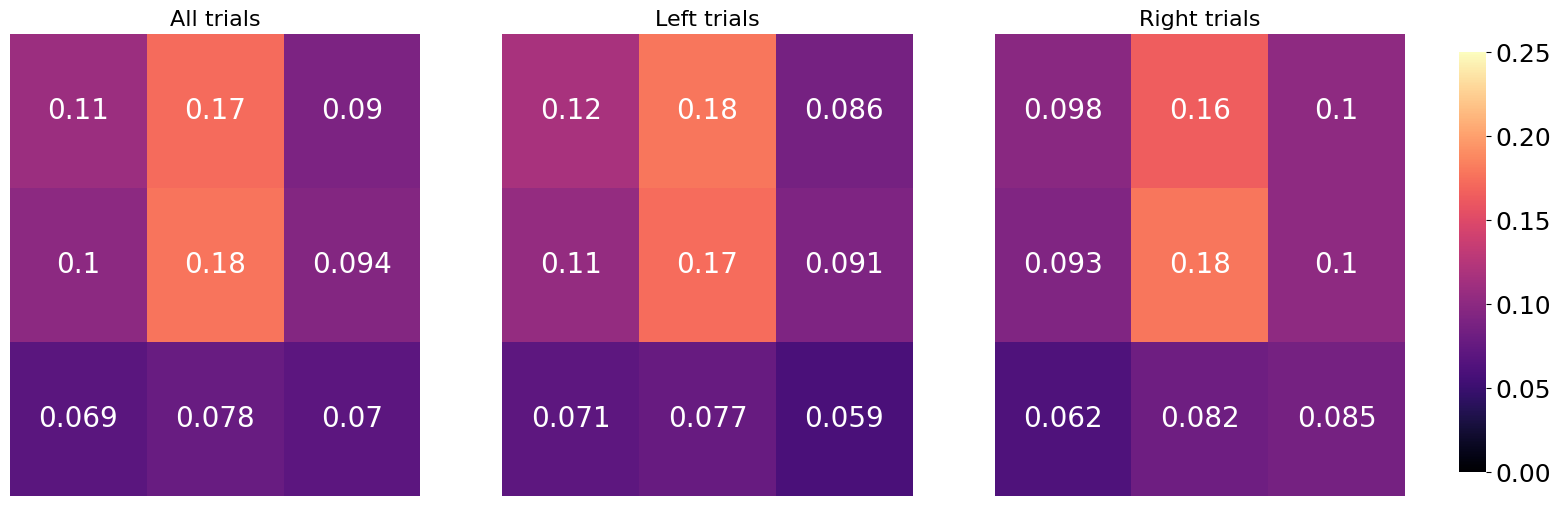

In [15]:
apertures = df_init.aperture.unique()
choices = sorted(df_init.trial_left_choice.unique())
hist_dict = {c: [] for c in choices}
session_hist = {c: {} for c in choices}
all_sessions_hists = []

for session in df_init.dataset.unique():
    session_df = df_init[df_init.dataset == session]
    
    # Calculate Full Histogram for this session
    full_hist = plotting.plot_init_position_histogram(
        session_df, box_df, ax=None, bins=3, is_density=False
    )
    n_total = session_df.groupby("trial").trial_init_x.first().count()
    all_sessions_hists.append(full_hist / n_total)
    
    # Calculate conditioned Histograms for this session
    for ch in choices:
        subset = session_df[(session_df.trial_left_choice == ch)]
        if not subset.empty:
            h = plotting.plot_init_position_histogram(
                subset, box_df, ax=None, bins=3, is_density=False
            )
            n_cond = subset.groupby("trial").trial_init_x.first().count()
            h_norm = h / n_cond
            hist_dict[ch].append(h_norm)
            session_hist[ch][session] = h_norm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax_full, ax_left, ax_right = axes
VMAX = 0.25
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

full_mean = np.mean(all_sessions_hists, axis=0)
sns.heatmap(
    np.flip(full_mean, axis=1).T,
    cmap="magma",
    annot=True,
    annot_kws={"size": 20},
    vmax=VMAX,
    vmin=0,
    ax=ax_full,
    cbar=False,
    )
ax_full.set_title("All trials", fontsize=16)

def _choice_label(choice_val):
    if choice_val == 1:
        return "Left"
    if choice_val == 0:
        return "Right"
    return f"Choice {choice_val}"

choice_axes = {}
if 1 in choices:
    choice_axes[1] = ax_left
if 0 in choices:
    choice_axes[0] = ax_right

remaining = [c for c in choices if c not in choice_axes]
if remaining and ax_left not in choice_axes.values():
    choice_axes[remaining.pop(0)] = ax_left
if remaining and ax_right not in choice_axes.values():
    choice_axes[remaining.pop(0)] = ax_right

plot_choices = [ch for ch in [1, 0] if ch in choice_axes]
if not plot_choices:
    plot_choices = list(choice_axes.keys())

for idx, ch in enumerate(plot_choices):
    ax = choice_axes[ch]
    if hist_dict[ch]:
        cond_mean = np.mean(hist_dict[ch], axis=0)
        sns.heatmap(
            np.flip(cond_mean, axis=1).T,
            cmap="magma",
            annot=True,
            annot_kws={"size": 20},
            vmax=VMAX,
            vmin=0,
            ax=ax,
            cbar=(idx == len(plot_choices) - 1),
            cbar_ax=(cbar_ax if idx == len(plot_choices) - 1 else None),
        )
    ax.set_title(f"{_choice_label(ch)} trials", fontsize=16)

# Formatting cleanup
for ax in [ax_full, ax_left, ax_right]:
    ax.set_xticks([])
    ax.set_yticks([])

#plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3, hspace=0.3)
fig.savefig(save_fig_path + "supp_contrast_initial_position_heatmaps.svg", dpi=300, bbox_inches="tight", transparent=True)

In [16]:
# Per-bin significance tests between choices
ch_order = sorted(choices)
sig_rows = []

def collect_choice_hist(c_val):
    return session_hist[c_val]

# Between choices
if len(ch_order) >= 2:
    shared_sessions = set(collect_choice_hist(ch_order[0]).keys()).intersection(
        collect_choice_hist(ch_order[1]).keys()
    )
    if shared_sessions:
        example_hist = collect_choice_hist(ch_order[0])[next(iter(shared_sessions))]
        for r, c in np.ndindex(example_hist.shape):
            vals_a = [collect_choice_hist(ch_order[0])[s][r, c] for s in shared_sessions]
            vals_b = [collect_choice_hist(ch_order[1])[s][r, c] for s in shared_sessions]
            if len(vals_a) < 2 or len(vals_b) < 2:
                continue
            t = ttest_rel(vals_a, vals_b)
            sig_rows.append(
                {
                    "comparison": "choice",
                    "level_a": ch_order[0],
                    "level_b": ch_order[1],
                    "bin_row": r,
                    "bin_col": c,
                    "p_value": t.pvalue,
                    "t_stat": t.statistic,
                    "n_sessions": len(vals_a),
                }
            )

sig_df = pd.DataFrame(sig_rows)
if not sig_df.empty:
    sig_df["p_value_corr"] = stats.false_discovery_control(sig_df.p_value)
    sig_df["significant"] = sig_df.p_value_corr < 0.05
    
sig_df

,comparison,level_a,level_b,bin_row,bin_col,p_value,t_stat,n_sessions,p_value_corr,significant
0,choice,0.0,1.0,0,0,0.533919,-0.637766,15,0.686467,False
1,choice,0.0,1.0,0,1,0.228558,-1.259174,15,0.667749,False
2,choice,0.0,1.0,0,2,0.083269,-1.865068,15,0.374709,False
3,choice,0.0,1.0,1,0,0.700740,0.392305,15,0.786856,False
4,choice,0.0,1.0,1,1,0.786856,0.275634,15,0.786856,False
5,choice,0.0,1.0,1,2,0.300112,-1.076020,15,0.667749,False
6,choice,0.0,1.0,2,0,0.004558,3.372211,15,0.041022,True
7,choice,0.0,1.0,2,1,0.449010,0.778890,15,0.673516,False
8,choice,0.0,1.0,2,2,0.370972,0.924332,15,0.667749,False


### Rate plots

In [17]:
trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

4.3: mean=0.741 ± 0.022
12.0-4.3: TtestResult(statistic=4.3469830719398646, pvalue=0.0006698811968695812, df=14)
12.0: mean=0.900 ± 0.019


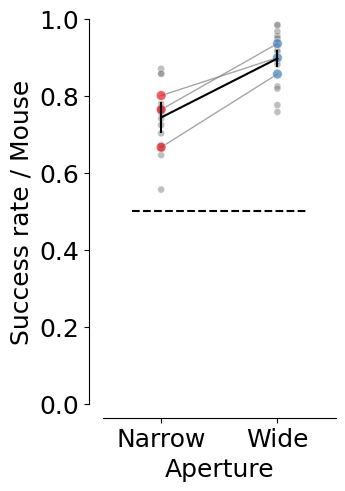

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Mouse")
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "supp_contrast_trial_reward.svg", transparent=True)

wide aperture mean:  0.508655783006373 std:  0.02774361461722577
narrow aperture mean:  0.49134421699362696 std:  0.027743614617225784


TtestResult(statistic=1.167366793078196, pvalue=0.262560598358068, df=14)

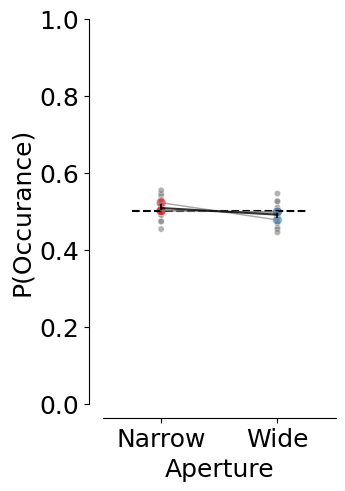

In [19]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Aperture")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "supp_contrast_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide aperture mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow aperture mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

4.3: mean=0.135 ± 0.085
12.0-4.3: TtestResult(statistic=-0.17219823726971856, pvalue=0.8657461439506684, df=14)
12.0: mean=0.116 ± 0.041
12.0 vs chance 0: t=1.74, p=0.223
4.3 vs chance 0: t=0.76, p=0.526


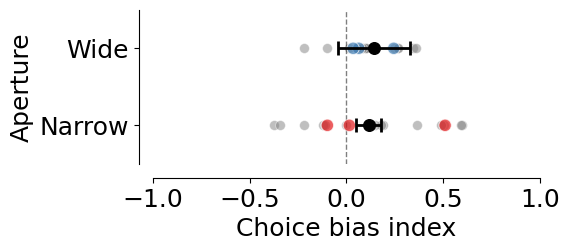

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([1, 0], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
sns.despine(offset=10)

plt.savefig(save_fig_path + "supp_contrast_choice_bias.svg", transparent=True)

In [22]:
# Stickiness of the decision
trial_df["trial_history"] = trial_df.groupby(
                    ["dataset"]
                )["trial_left_choice"].transform(lambda x: x.shift(1)).fillna(0)

trial_df["decision_stickiness"] = (
    (trial_df['trial_left_choice'] == trial_df['trial_history'])
    .groupby([trial_df['dataset'], trial_df['trial']])
    .transform('mean')
)

4.3: mean=0.009 ± 0.033
12.0-4.3: TtestResult(statistic=0.03758014588624681, pvalue=0.9705530506869855, df=14)
12.0: mean=0.010 ± 0.022
12.0 vs chance 0: t=0.32, p=0.782
4.3 vs chance 0: t=0.15, p=0.893


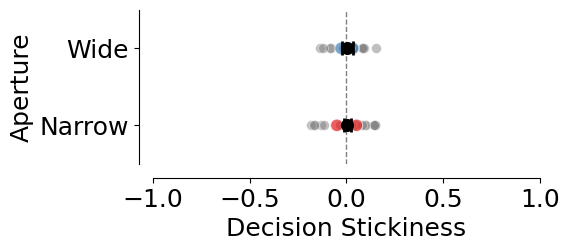

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="decision_stickiness",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
    plot_bias=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Aperture")
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Decision Stickiness")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "supp_contrast_decision_stickiness.svg", transparent=True)

Overall Win-Stay rate: 0.4063729897888339 sem: 0.012949888102893707
Overall Lose-Switch rate: 0.0779615802678051 sem: 0.003477881357920265
Paired win-stay vs lose-switch: TtestResult(statistic=21.307977771939456, pvalue=4.220834933783766e-06, df=5)
Win-stay vs 0.5: TtestResult(statistic=-7.229947430221018, pvalue=0.000789751253341522, df=5)
Lose-switch vs 0.5: TtestResult(statistic=-121.34928604481473, pvalue=7.207784545731377e-10, df=5)


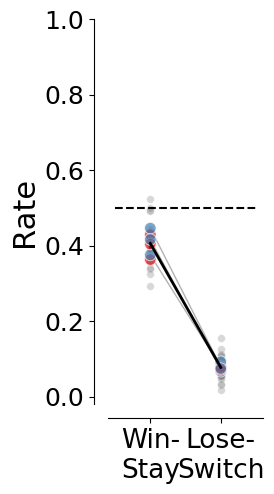

In [24]:
# Win-Stay / Lose-Switch analysis
wsls_df = trial_df.sort_values(["dataset", "trial", "aperture"]).copy()
wsls_df["prev_choice"] = wsls_df.groupby("dataset")["trial_left_choice"].shift(1)
wsls_df["prev_reward"] = wsls_df.groupby("dataset")["trial_rewarded"].shift(1)

wsls_df = wsls_df.dropna(subset=["prev_choice", "prev_reward"])
wsls_df["win_stay"] = (wsls_df["prev_reward"] == 1) & (wsls_df["trial_left_choice"] == wsls_df["prev_choice"])
wsls_df["lose_switch"] = (wsls_df["prev_reward"] == 0) & (wsls_df["trial_left_choice"] != wsls_df["prev_choice"])

wsls_summary = (
    wsls_df.groupby(["mouse_name", "aperture"], as_index=False)[["win_stay", "lose_switch"]].mean()
)
print("Overall Win-Stay rate:", wsls_summary["win_stay"].mean(), "sem:", wsls_summary["win_stay"].sem())
print("Overall Lose-Switch rate:", wsls_summary["lose_switch"].mean(), "sem:", wsls_summary["lose_switch"].sem())
wsls_session = (
    wsls_df.groupby(["dataset", "aperture"], as_index=False)[["win_stay", "lose_switch"]].mean()
)

# Significance tests
if len(wsls_summary) > 1:
    wsls_rel = ttest_rel(wsls_summary["win_stay"], wsls_summary["lose_switch"])
    wsls_win_vs_chance = stats.ttest_1samp(wsls_summary["win_stay"], 0.5)
    wsls_lose_vs_chance = stats.ttest_1samp(wsls_summary["lose_switch"], 0.5)
    print("Paired win-stay vs lose-switch:", wsls_rel)
    print("Win-stay vs 0.5:", wsls_win_vs_chance)
    print("Lose-switch vs 0.5:", wsls_lose_vs_chance)

fig, ax = plt.subplots(1, 1, figsize=(2, 5))

metric_order = ["win_stay", "lose_switch"]
metric_labels = {"win_stay": "Win-\nStay", "lose_switch": "Lose-\nSwitch"}

wsls_long = wsls_summary.melt(id_vars=["mouse_name", "aperture"], var_name="metric", value_name="rate")
wsls_long["metric"] = pd.Categorical(wsls_long["metric"], categories=metric_order, ordered=True)

wsls_session_long = wsls_session.melt(id_vars=["dataset", "aperture"], var_name="metric", value_name="rate")
wsls_session_long["metric"] = pd.Categorical(wsls_session_long["metric"], categories=metric_order, ordered=True)

# Connect dots from the same mouse across conditions
sns.lineplot(
    data=wsls_long,
    x="metric",
    y="rate",
    units="mouse_name",
    estimator=None,
    color="grey",
    alpha=0.6,
    linewidth=1,
    ax=ax,
    zorder=1,
    sort=False,
    )

# Dots only
sns.scatterplot(
    data=wsls_session_long,
    x="metric",
    y="rate",
    ax=ax,
    color="grey",
    s=30,
    alpha=0.3,
    zorder=2,
)

sns.scatterplot(
    data=wsls_long,
    x="metric",
    y="rate",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture[0:2],
    s=70,
    alpha=0.7,
    zorder=3,
)

sns.lineplot(
        data=wsls_long,
        x="metric",
        y="rate",
        color="black",
        errorbar="se",
        err_style="bars",
        linewidth=2,
        zorder=4,
        legend=False,
    )

plt.hlines(0.5, xmin=-0.5, xmax=1.5, linestyles="dashed", colors="k")
ax.set_ylim(-0.02, 1)
ax.set_ylabel("Rate", fontsize=22)
ax.set_xlabel("")
ax.set_xticks([0, 1])
ax.set_xticklabels([metric_labels[m] for m in metric_order])
ax.tick_params(axis="x", labelsize=19)
plt.legend([], [], frameon=False)
sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_wsls_rates.svg", transparent=True)

1.4176879630626178
mean 4.3: 1.4856734439794237
sem 4.3: 0.03800025642358789
12.0-4.3: TtestResult(statistic=-2.928266220915302, pvalue=0.01100929582777589, df=14)
mean 12.0: 1.3577983442140125
sem 12.0: 0.030989024172238033


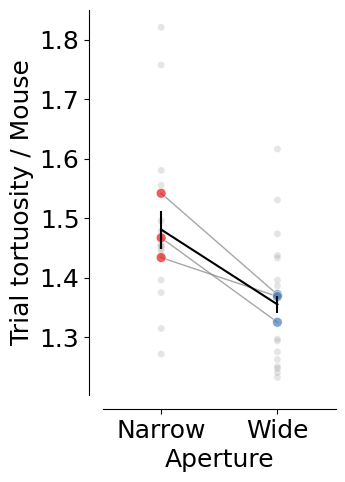

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

print(counts.groupby(["mouse_name", "aperture"]).mean(numeric_only=True).trial_tortuosity.mean())

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Trial tortuosity / Mouse")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["trial_tortuosity"],
                counts[counts["aperture"] == j]["trial_tortuosity"],
            )
            print(f"{i}-{j}: {stat}")
            
    print(f"mean {i}: {np.mean(counts[counts['aperture'] == i]['trial_tortuosity'])}")
    print(f"sem {i}: {stats.sem(counts[counts['aperture'] == i]['trial_tortuosity'])}")
plt.savefig(save_fig_path + "supp_contrast_trial_tortuosity.svg", transparent=True)

Overall mean:  0.95128327247454 0.008728677583401985


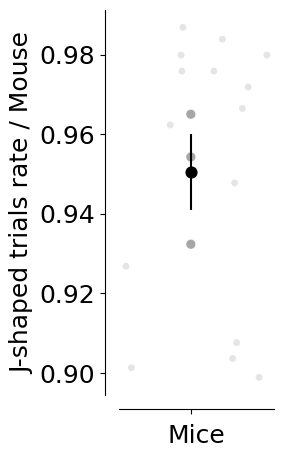

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(2, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset"], as_index=False)
    .trial_jshaped.mean()
)

counts["count"] = counts["trial_jshaped"]
counts = pd.DataFrame(counts.reset_index())

plotting._plot_bar_counts(
    counts=counts,
    label_x=None,
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=["grey"],
)

ax.set_ylabel("J-shaped trials rate / Mouse")
ax.set_xlabel("Mice")
plt.legend([], [], frameon=False)
sns.despine(offset=10)

print(f"Overall mean: ", np.mean(counts['trial_jshaped']), stats.sem(counts['trial_jshaped']))
plt.savefig(save_fig_path + "supp_contrast_trial_jshaped.svg", transparent=True)

## Trajectory analysis

In [47]:
xy_df = []
for m in mouse_list:
    print(m)
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df["mouse_name"] = xy_df.dataset.str.split("_").str [0]

Flamingo_2026-02-02_1
Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


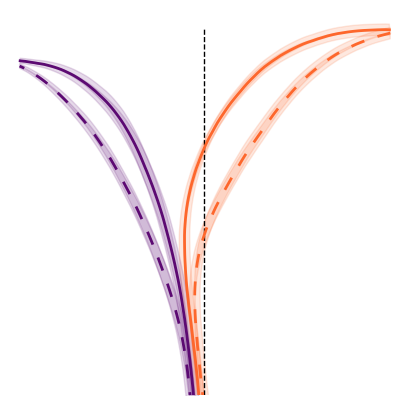

In [49]:
# Mean and error by session
mean_session = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_session, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories
plotting.plot_mean_xy_trajectory(mean_group, cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.svg", transparent=True)
plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.png", transparent=True, dpi=300)

In [50]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df, 
                                         index_columns= [
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

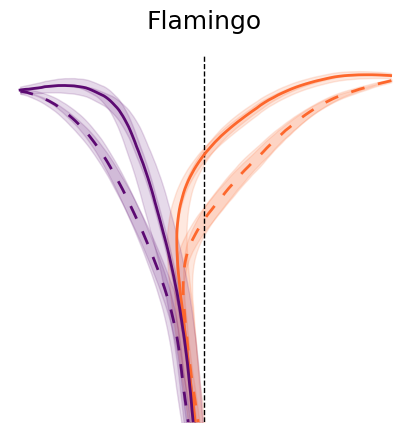

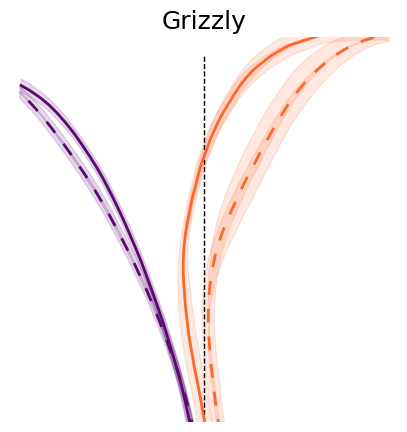

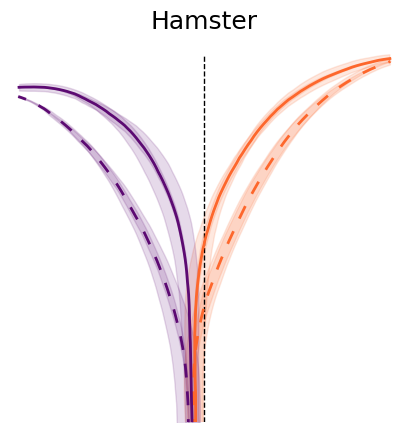

In [51]:
for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], 
                                     cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
    plt.title(m)
    plt.savefig(save_fig_path + f"supp_contrast_dual_occluders_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"supp_contrast_dual_occluders_trajectories_time_{m}.png", transparent=True, dpi=300)

In [124]:
y_binned_df = []
for m in mouse_list:
    try:
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", "trial_left_choice", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

In [126]:
y_binned_df["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df, 
                         spatial_ybins=[-13, 24, 30])
y_binned_df_mean = analysis.mean_xy_trajectory(data, 
                                               index_columns=["dataset", "mouse_name", "aperture", "bin_centers"], 
                                               values=["x_flipped", "y"])

                        Anova
                     F Value   Num DF  Den DF  Pr > F
-----------------------------------------------------
aperture              11.9600  1.0000  14.0000 0.0038
bin_centers          221.9727 14.0000 196.0000 0.0000
aperture:bin_centers   5.7969 14.0000 196.0000 0.0000



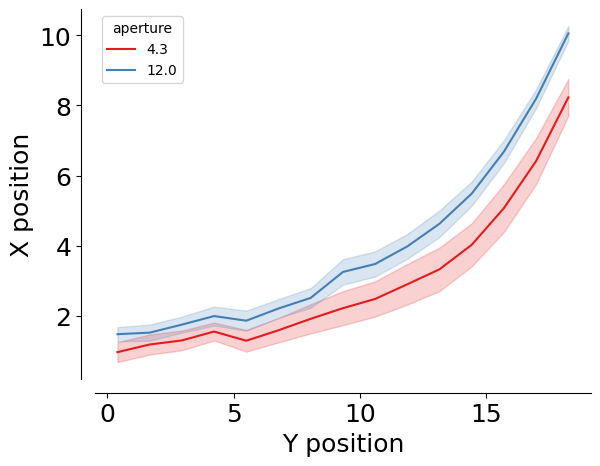

In [130]:
stats_binned = y_binned_df_mean[(y_binned_df_mean.bin_centers >= 0) & (y_binned_df_mean.bin_centers < 19)]

sns.lineplot(data=stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se")
plt.xlabel("Y position")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "supp_contrast_mean_xy_trajectory.svg", transparent=True)

print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

In [134]:
p_values = []
for i in stats_binned.bin_centers.unique():
    section = stats_binned [stats_binned.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

In [147]:
# Closest value to 0.05 in the corrected p-values
cross_sign = p_value_df[p_value_df.p_value_corr <= 0.05].iloc[0]

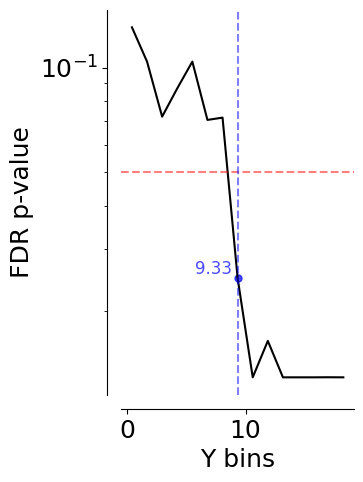

In [162]:
fig = plt.figure(figsize=(3, 5))
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("FDR p-value")
plt.yscale("log")
plt.axvline(x=cross_sign.segment, linestyle="dashed", color="blue", alpha=0.5)
# add the value of the y position at the crossing point
plt.text(cross_sign.segment - 0.5, cross_sign.p_value_corr, f"{cross_sign.segment:.2f}", 
         color="blue", fontsize=12, verticalalignment="bottom", horizontalalignment="right", alpha=0.7)
plt.scatter(data=cross_sign, x="segment", y="p_value_corr", color="blue", alpha=0.7)
sns.despine(offset=10)
plt.savefig(save_fig_path + "supp_contrast_position_p_values.svg", transparent=True)

In [66]:
velocity_df = []
for m in mouse_list:
    print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

Flamingo_2026-02-02_1
Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


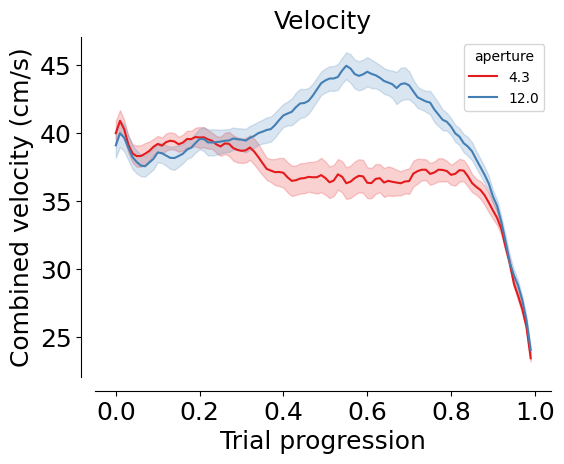

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax

sns.lineplot(
    data=velocity_df,
    x="trial_length",
    y="velocity",
    palette=(
        plotting.colors_aperture[:2]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_aperture[:2]
    ),
    hue="aperture",
    errorbar="se",
    ax=ax,
)
ax.set_title(f"Velocity")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "supp_contrast_mean_velocity.svg", transparent=True)

In [68]:
print(
    AnovaRM(
        data=velocity_df,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              63.0720  1.0000   14.0000 0.0000
trial_length          46.3908 99.0000 1386.0000 0.0000
aperture:trial_length 22.2189 99.0000 1386.0000 0.0000



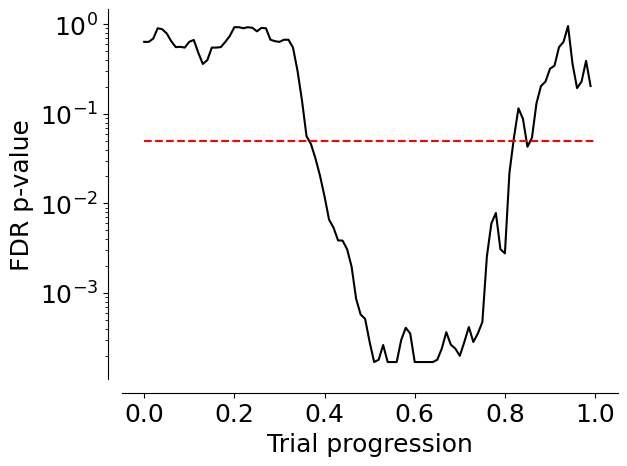

In [69]:
p_values = []
for i in velocity_df.trial_length.unique():
    section = velocity_df[velocity_df.trial_length == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].velocity,
        section[section.aperture == section.aperture.unique()[1]].velocity,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "supp_contrast_velocity_pvalue.svg", transparent=True)

In [70]:
# TODO This fecth call is a little slow, maybe we should add an optimal p table
optimal_df = []
for m in mouse_list:
    print(m)
    optimal_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "trial", "aperture", "optimal_p", as_dict=True)[0]))
optimal_df = pd.concat(optimal_df)

# Create list of included datasets
mouse_list = optimal_df.dataset.unique()
optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]

optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

Flamingo_2026-02-02_1
Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


In [71]:
optimal_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

mean 4.3: 14.73409324511116
sem 4.3: 1.1211647591569753
12.0-4.3: TtestResult(statistic=-2.741191996403561, pvalue=0.015917849074639428, df=14)
mean 12.0: 13.210398985341383
sem 12.0: 0.9594091335646505


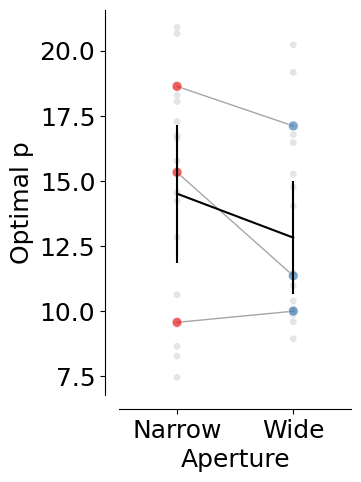

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Optimal p")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

    print(f"mean {i}: {np.mean(counts[counts['aperture'] == i]['optimal_p'])}")
    print(f"sem {i}: {stats.sem(counts[counts['aperture'] == i]['optimal_p'])}")
plt.savefig(save_fig_path + "supp_contrast_fitted_p.svg", transparent=True)

In [73]:
counts.groupby("aperture").optimal_p.mean(), counts.groupby("aperture").optimal_p.sem()

(aperture
 12.0    13.210399
 4.3     14.734093
 Name: optimal_p, dtype: float64,
 aperture
 12.0    0.959409
 4.3     1.121165
 Name: optimal_p, dtype: float64)

## Regression model

In [74]:
# This takes a while to fetch because we need to fetch data for all trials
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]

Flamingo_2026-02-02_1
Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


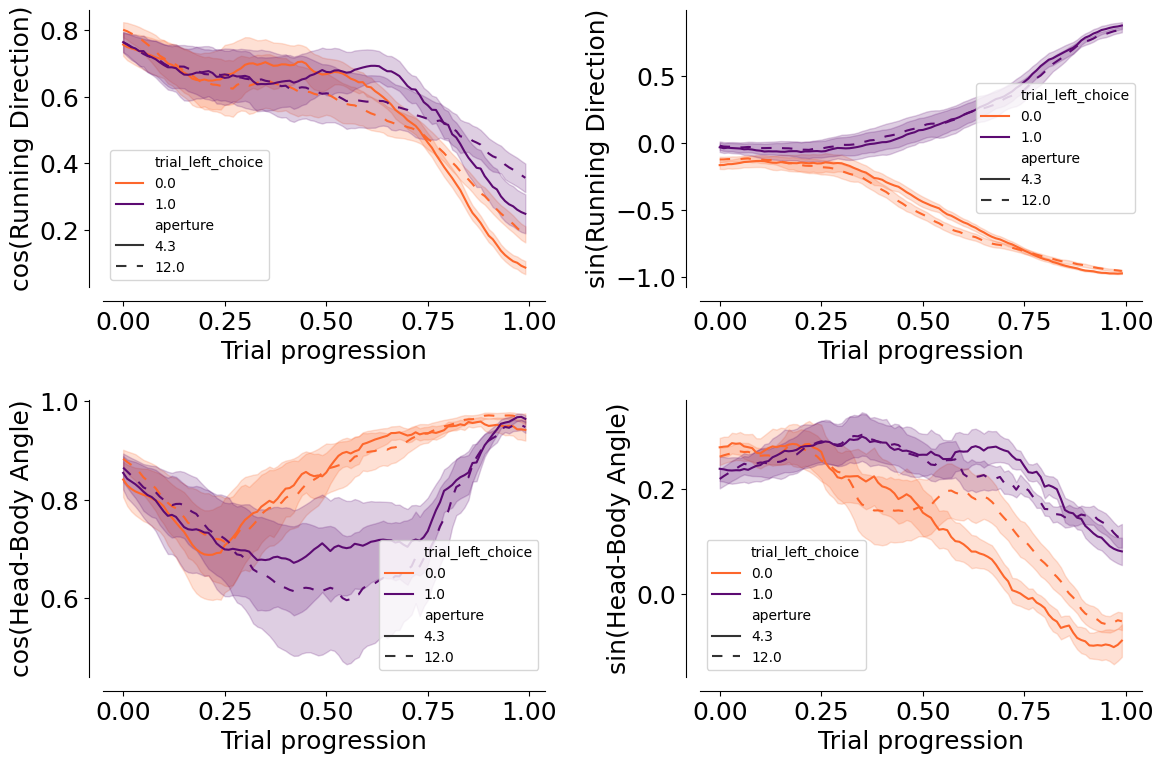

In [75]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        dashes=dash_styles,
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "supp_contrast_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)

In [76]:
task_type_key = {"set_name": "contrast_black_target",
                 "stage_name": "dual_occlusion"}

In [77]:
model_key = {"label_set_id": 8, "params_id": 1}

In [78]:
# Coefficients for dual occluder task
coef = (PredictionModel() & model_key & task_type_key).fetch1("coefficients")

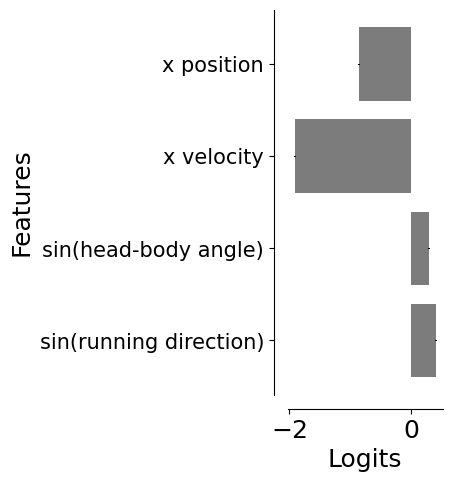

In [79]:
# Logits of the regression
model_labels, clean_labels = (LabelSet.Member * Label & model_key).fetch("label_key", "clean_name")

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(model_labels)))
ax.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(save_fig_path + "supp_contrast_model_logits.svg", transparent=False)

In [80]:
prediction_df = pd.DataFrame((PredictionModel().SessionPrediction() & model_key & task_type_key).fetch(
    "dataset", "trial", "proba_left", "accuracy", "trial_length", as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length"])

In [81]:
df_model = prediction_df.merge(
    interpolated_df[["dataset", "trial_length", "trial", "aperture", "trial_left_choice", "x", "y"]], on=["dataset", "trial", "trial_length"]
)

df_model["accuracy"] = df_model["accuracy"].astype(float)
df_model["proba_left"] = df_model["proba_left"].astype(float)

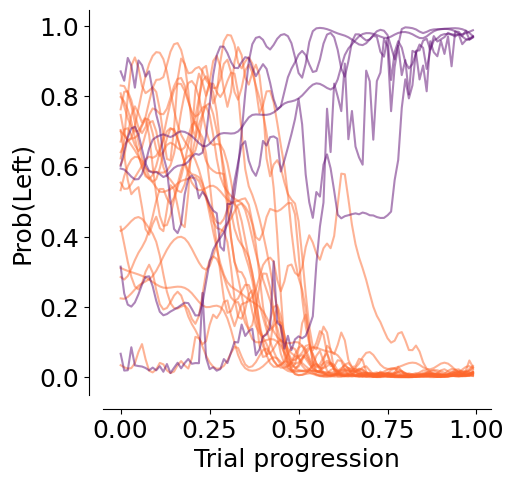

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = df_model[(df_model.dataset == "Flamingo_2026-02-09_1")]

trials = [
    94,
    15,
    66,
    170,
    224,
    195,
    56,
    203,
    88,
    239,
    113,
    91,
    186,
    248,
    109,
    164,
    188,
    60,
    229,
    182,
    156,
    197,
    52,
    45,
]

group = group[group.trial.isin(np.array(trials))]
sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=0.5,
    ax=ax,
)
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "supp_contrast_dynamic_decision_variable.svg",
    transparent=True,
)

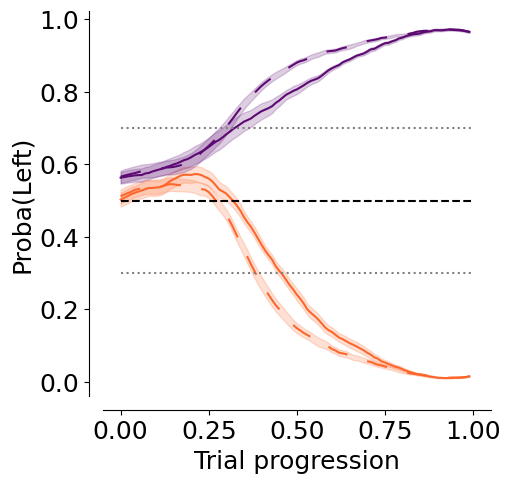

In [83]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    style="aperture",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se",
    dashes=dash_styles
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.7, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.3, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "supp_contrast_dynamic_decision_variable_avg.png",
    transparent=True,
    dpi=300,
)

plt.savefig(
    save_fig_path + "supp_contrast_dynamic_decision_variable_avg.svg",
    transparent=True,
)

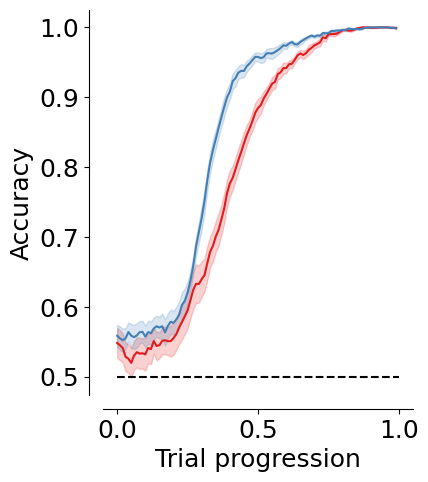

In [84]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

fig, ax = plt.subplots(1, 1, figsize=(4, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="accuracy",
    hue="aperture",
    palette=plotting.colors_aperture,
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "supp_contrast_model_accuracy.svg", transparent=True
)

In [85]:
decision_points = pd.DataFrame((DecisionPoints() & task_type_key & model_key & "threshold_uncertainty = 0.2").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str[0]

In [93]:
with open("notebooks/Paper_figures/info_matrix_52x52x31_124.npy", "rb") as file:
    info_matrix_narrow = np.rot90(np.load(file), k=1)
with open("notebooks/Paper_figures/info_matrix_52x52x31_346.npy", "rb") as file:
    info_matrix_wide = np.rot90(np.load(file), k=1)

info_matrices = [info_matrix_narrow, info_matrix_wide]

# normalize info matrices to max 1
info_matrices = [im / im.max() for im in info_matrices]

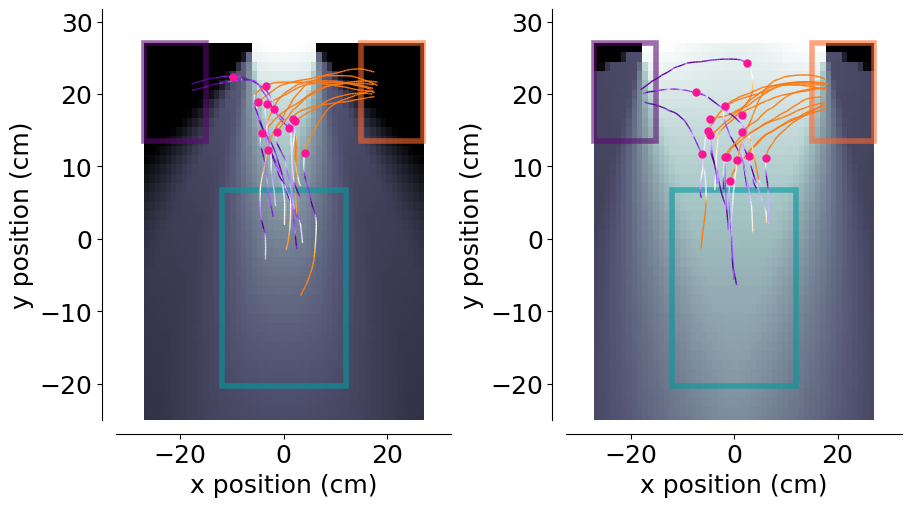

In [94]:
fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(9, 5), constrained_layout=True
)

decision_color = "deeppink"
session_to_plot = "Flamingo_2026-02-09_1"

trials = [44, 45, 19, 62, 61, 45, 85, 41, 43, 41, 50, 75, 24, 69, 84, 74, 10] + [
    63,
    30,
    78,
    47,
    33,
    5,
    17,
    9,
    47,
    30,
    99,
    11,
    12,
    15,
]

# Start from PuOr
base_cmap = cm.get_cmap("PuOr")

# Make a brighter version by rescaling luminance
def brighten(cmap, factor=2):
    colors = cmap(np.linspace(0, 1, 256))
    rgb = mcolors.rgb_to_hsv(colors[:, :3])
    rgb[:, 2] = rgb[:, 2] * factor  # brighten value channel
    rgb[:, 2] = np.clip(rgb[:, 2], 0, 1)
    colors[:, :3] = mcolors.hsv_to_rgb(rgb)
    return mcolors.ListedColormap(colors)

bright_puor = brighten(base_cmap)

for i, aperture in enumerate(df_model.aperture.unique()[::-1]):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
        cmap=bright_puor,
    )
    
    xlim = ax[i].get_xlim()
    ylim = ax[i].get_ylim()

    im = ax[i].imshow(info_matrices[i], 
                 cmap="bone", 
                 extent=[-27, 27, -27, 27],
                 zorder=-10)
    
    ax[i].set_xlim(xlim)
    ax[i].set_ylim(ylim)
    ax[i].set_aspect(1.4)
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
    sns.despine(offset=10, ax=ax[i])

#fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.03, pad=0.04, label="Information content rate")
plt.savefig(
    save_fig_path + "supp_contrast_decision_points_trajectories_bright.svg",
    transparent=True,
)

mean: 13.86564617811223 +/- 0.5386939023469558
12.0-4.3: TtestResult(statistic=-4.592982876939882, pvalue=0.00041800924735993993, df=14)
 mean difference:  3.6491137828863707
mean: 10.21653239522586 +/- 0.4492331557704968


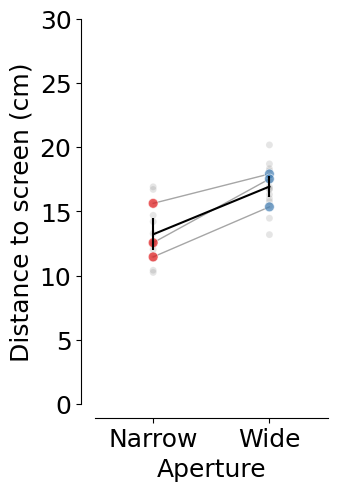

In [95]:
decision_points["y"] = decision_points.y.astype(float)

fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats_res = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_mouse=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 30)
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "supp_contrast_decision_points_distance.svg",
    transparent=True,
)

## Direct comparison

In [96]:
trial_df_white = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df_white =  pd.concat([pd.DataFrame(x) for x in trial_df_white])

# Exclude sessions that were not in the list
trial_df_white, reward_table = utils.apply_inclusion_criteria(trial_df_white,
                                                        return_excluded=False)

# Create list of included datasets
mouse_list_white = trial_df_white.dataset.unique()
trial_df_white["mouse_name"] = trial_df_white.dataset.str.split("_").str[0]

In [121]:
y_binned_df_white = []
for m in mouse_list_white:
    try:
        y_binned_df_white.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", "trial_left_choice", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df_white = pd.concat(y_binned_df_white)

In [163]:
y_binned_df_white["mouse_name"] = y_binned_df_white.dataset.str.split("_").str [0]
y_binned_df_white["x_flipped"] = y_binned_df_white.x * y_binned_df_white.flip_one_side
y_binned_df_white_mean = analysis.mean_xy_trajectory(utils.create_bins(y_binned_df_white,
                                                                  spatial_ybins=[-13, 24, 30]), index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

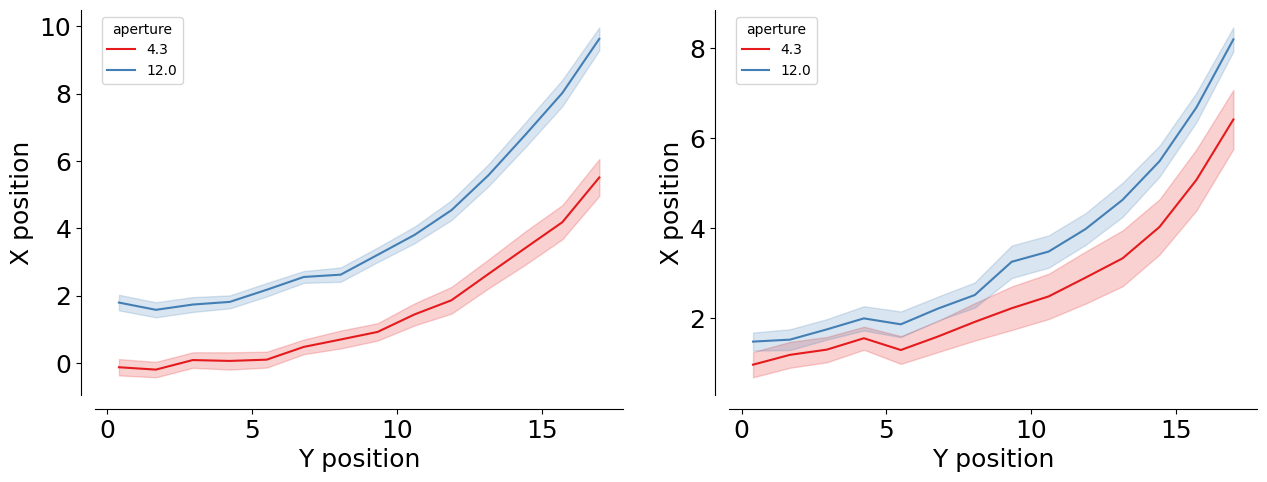

In [165]:
stats_binned_white = y_binned_df_white_mean[(y_binned_df_white_mean.bin_centers >= 0) & (y_binned_df_white_mean.bin_centers <= 18)]
stats_binned = y_binned_df_mean[(y_binned_df_mean.bin_centers >= 0) & (y_binned_df_mean.bin_centers <= 18)]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data = stats_binned_white, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se", ax=ax[0])
ax[0].set_xlabel("Y position")
ax[0].set_ylabel("X position")


sns.lineplot(data = stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se", ax=ax[1])
ax[1].set_xlabel("Y position")
ax[1].set_ylabel("X position")

sns.despine(offset=10)

In [167]:
p_values_white = []
for i in stats_binned_white.bin_centers.unique():
    section = stats_binned_white[stats_binned_white.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values_white.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df_white = pd.concat(p_values_white)
p_value_df_white["p_value_corr"] = stats.false_discovery_control(p_value_df_white.p_value)

In [169]:
# Assign labels
stats_binned_white['source'] = 1
stats_binned['source'] = 0

# Vertical append
df_combined = pd.concat([stats_binned_white, stats_binned], ignore_index=True)

In [171]:
def calculate_cohen_d(group0, group1):
    """Calculates Cohen's d for two independent samples."""
    n0, n1 = len(group0), len(group1)
    # Degrees of freedom
    dof = n0 + n1 - 2
    # Pooled Standard Deviation
    # Using ddof=1 for unbiased variance estimate
    var0 = np.var(group0, ddof=1)
    var1 = np.var(group1, ddof=1)
    pooled_std = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / dof)
    
    # Calculate d (difference of means over pooled std)
    if pooled_std == 0:
        return 0
    return (np.mean(group0) - np.mean(group1)) / pooled_std

comp_rows = []
for (ap, b), g in df_combined.groupby(["aperture", "bin_centers"]):
    vals_0 = g[g["source"] == 0]["x_flipped"].dropna()
    vals_1 = g[g["source"] == 1]["x_flipped"].dropna()
    
    # Increased minimum N to 3 for slightly better stability
    if len(vals_0) < 3 or len(vals_1) < 3:
        continue
        
    # Welch's t-test (handles unequal variance and unequal n)
    t_res = stats.ttest_ind(vals_0, vals_1, equal_var=False)
    
    # Cohen's d for effect size
    d_val = calculate_cohen_d(vals_0, vals_1)
    
    comp_rows.append(
        {
            "aperture": ap,
            "bin_centers": b,
            "n_source0": len(vals_0),
            "n_source1": len(vals_1),
            "t_stat": t_res.statistic,
            "p_value": t_res.pvalue,
            "cohen_d": d_val
        }
    )

per_bin_results = pd.DataFrame(comp_rows).sort_values(["aperture", "bin_centers"])

if not per_bin_results.empty:
    # FDR correction within each aperture
    per_bin_results["p_value_corr"] = (
        per_bin_results.groupby("aperture")["p_value"]
        .transform(lambda s: stats.false_discovery_control(s))
    )
    per_bin_results["significant"] = per_bin_results["p_value_corr"] < 0.05

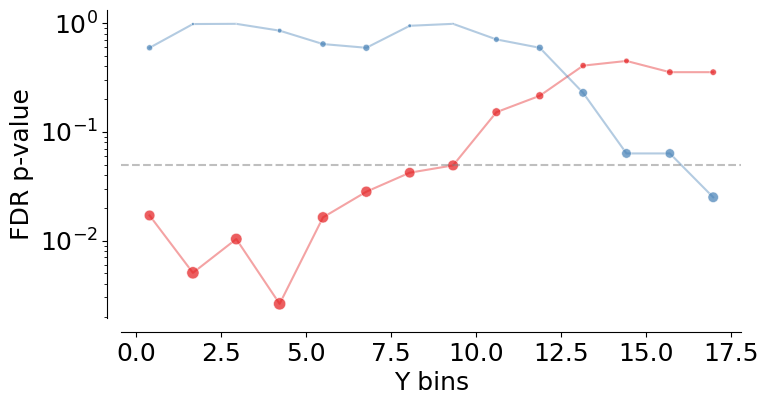

In [ ]:
# Plot the p-values across bins for each aperture
apertures_sorted = sorted(per_bin_results["aperture"].unique())
colors = plotting.colors_aperture[:len(apertures_sorted)]
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for ap, color in zip(apertures_sorted, colors):
    sub = per_bin_results[per_bin_results["aperture"] == ap]
    
    ax.plot(sub["bin_centers"], 
            sub["p_value_corr"], 
            color=color, 
            linewidth=1.5, 
            label=f"Aperture {ap}",
            alpha=0.4,
            zorder=1
            )
    
    ax.scatter(
        sub["bin_centers"],
        sub["p_value_corr"],
        color=color,
        s=sub["cohen_d"].abs() * 80, 
        alpha=0.7,
        edgecolor="white",
        linewidths=0.5,
        zorder=2
    )

# Significance threshold
ax.axhline(0.05, linestyle="--", color="grey", alpha=0.5)

# Formatting
ax.set_ylabel("FDR p-value")
ax.set_xlabel("Y bins")
ax.set_yscale('log')

sns.despine(ax=ax, offset=10)
plt.savefig(save_fig_path + "supp_contrast_position_p_values_with_effect_size.svg", transparent=True)